# Template Example Notebook

This is a template notebook. The first heading should be the title of what notebook is about. For example, if it is a project on neo4j tutorial the heading should be `Project Title`.

- Add description of what the notebook does.
- Point to references, e.g. (neo4j.example.md)
- Add citations.
- Keep the notebook flow clear.
- Comments should be imperative and have a period at the end.
- Your code should be well commented. 

The name of this notebook should in the following format:
- if the notebook is exploring `pycaret API`, then it is `pycaret.example.ipynb`

Follow the reference to write notebooks in a clear manner: https://github.com/causify-ai/helpers/blob/master/docs/coding/all.jupyter_notebook.how_to_guide.md

In [2]:
import logging
# Import libraries in this section.
# Avoid imports like import *, from ... import ..., from ... import *, etc.

import helpers.hdbg as hdbg
import helpers.hprint as hprint

In [3]:
hdbg.init_logger(verbosity=logging.INFO)

_LOG = logging.getLogger(__name__)

hprint.config_notebook()

INFO  > cmd='/venv/lib/python3.12/site-packages/ipykernel_launcher.py -f /home/.local/share/jupyter/runtime/kernel-783e0930-1631-4d64-8bb4-f3a98bb74fcd.json'


## Make the notebook flow clear
Each notebook needs to follow a clear and logical flow, e.g:
- Load data
- Compute stats
- Clean data
- Compute stats
- Do analysis
- Show results

In [5]:
class Template:
    """
    Brief imperative description of what the class does in one line, if needed.
    """
    def __init__(self):
        pass
    
    def method1(self, arg1:int) -> None:
        """
        Brief imperative description of what the method does in one line.

        You can elaborate more in the method docstring in this section, for e.g. explaining 
        the formula/algorithm. Every method/function should have a docstring, typehints and include the
        parameters and return as follows:

        :param arg1: description of arg1
        :return: description of return
        """
        # Code bloks go here.
        # Make sure to include comments to explain what the code is doing.
        # No empty lines between code blocks.
        pass


def template_function(arg1:int) -> None:
    """
    Brief imperative description of what the function does in one line.

    You can elaborate more in the function docstring in this section, for e.g. explaining 
    the formula/algorithm. Every function should have a docstring, typehints and include the
    parameters and return as follows:

    :param arg1: description of arg1
    :return: description of return
    """
    # Code bloks go here.
    # Make sure to include comments to explain what the code is doing.
    # No empty lines between code blocks.
    pass


## The flow should be highlighted using headings in markdown
```
# Level 1
## Level 2
### Level 3
```

In [30]:
import requests

# URL to get current Bitcoin price in USD
url = "https://api.coingecko.com/api/v3/simple/price?ids=bitcoin&vs_currencies=usd"

# Make the API call
response = requests.get(url)
data = response.json()

# Extract the price
btc_price = data['bitcoin']['usd']
print(f"Current Bitcoin Price: ${btc_price}")


Current Bitcoin Price: $103741


In [31]:
import pandas as pd
import requests

# Define URL for historical Bitcoin market chart (last 90 days, daily interval)
url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
params = {"vs_currency": "usd", "days": "90", "interval": "daily"}  # last 90 days

# Make request
response = requests.get(url, params=params)
data = response.json()

# Extract price data
prices = data["prices"]  # each item: [timestamp in ms, price]

# Convert to DataFrame
df = pd.DataFrame(prices, columns=["timestamp", "price"])
df["date"] = pd.to_datetime(df["timestamp"], unit="ms")
df = df[["date", "price"]]

# Show result
df.head()

,date,price
0,2025-02-16,97569.951694
1,2025-02-17,96149.348455
2,2025-02-18,95776.157239
3,2025-02-19,95495.891533
4,2025-02-20,96554.871563


In [32]:
# Make sure 'date' is datetime and sorted
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Calculate 30-day rolling average and standard deviation
df['avg_price_30d'] = df['price'].rolling(window=30).mean()
df['volatility_30d'] = df['price'].rolling(window=30).std()

# View the result
print(df[['date', 'price', 'avg_price_30d', 'volatility_30d']].tail())





                  date          price  avg_price_30d  volatility_30d
86 2025-05-13 00:00:00  102876.830429   93347.306169     6585.852305
87 2025-05-14 00:00:00  104184.490393   94033.428512     6607.617657
88 2025-05-15 00:00:00  103594.425751   94669.127621     6578.458434
89 2025-05-16 00:00:00  103708.851364   95337.539583     6438.147575
90 2025-05-16 01:10:39  103740.733266   95992.038045     6252.317536


In [33]:
import requests
import pandas as pd

# Replace with your actual Alpha Vantage API key
api_key = "REDACTED_FOR_SECURITY"



url = "https://www.alphavantage.co/query"
params = {
    "function": "TIME_SERIES_DAILY",
    "symbol": "XAUUSD",  # Gold in USD
    "apikey": api_key,
    "outputsize": "compact"
}

response = requests.get(url, params=params)
data = response.json()

# Extract and format data
gold_data = data['Time Series (Daily)']
gold_df = pd.DataFrame.from_dict(gold_data, orient='index')
gold_df = gold_df.rename(columns={"4. close": "gold_price"})
gold_df["gold_price"] = gold_df["gold_price"].astype(float)
gold_df.index = pd.to_datetime(gold_df.index)
gold_df = gold_df.sort_index().reset_index().rename(columns={"index": "date"})

gold_df = gold_df[["date", "gold_price"]]


In [34]:
# Ensure date formats and sort
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
gold_df = gold_df.sort_values('date')

# Merge and calculate rolling correlation
merged_df = pd.merge(df, gold_df, on='date', how='inner')
merged_df['rolling_corr_30d'] = merged_df['price'].rolling(30).corr(merged_df['gold_price'])


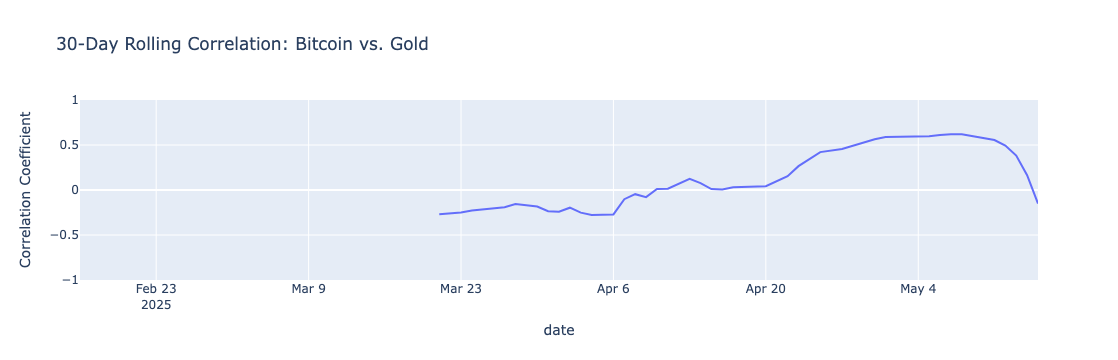

In [35]:
import plotly.express as px

fig = px.line(
    merged_df,
    x='date',
    y='rolling_corr_30d',
    title='30-Day Rolling Correlation: Bitcoin vs. Gold',
    labels={'rolling_corr_30d': 'Correlation Coefficient'}
)
fig.update_layout(yaxis=dict(range=[-1, 1]))
fig.show()





In [36]:
# Step 1: Calculate daily % change in price
df['pct_change'] = df['price'].pct_change() * 100  # in percentage

# Step 2: Flag large negative changes
anomalies_df = df[df['pct_change'] <= -5]

# Step 3: View the anomalies
print(anomalies_df[['date', 'price', 'pct_change']])



         date         price  pct_change
9  2025-02-25  91396.766869   -5.118682
11 2025-02-27  83900.114965   -5.470804
16 2025-03-04  86124.714187   -8.632173
22 2025-03-10  80751.138933   -6.259180
50 2025-04-07  78211.483582   -6.440989


In [37]:
df['shock'] = df['pct_change'] <= -5

In [38]:
# Calculate daily percentage change
df['pct_change'] = df['price'].pct_change() * 100

# Filter for days with more than 5% drop
anomalies_df = df[df['pct_change'] <= -5]

# View results
print(anomalies_df[['date', 'price', 'pct_change']])




         date         price  pct_change
9  2025-02-25  91396.766869   -5.118682
11 2025-02-27  83900.114965   -5.470804
16 2025-03-04  86124.714187   -8.632173
22 2025-03-10  80751.138933   -6.259180
50 2025-04-07  78211.483582   -6.440989


In [47]:
from prophet import Prophet

# Step 1: Prepare data
btc_for_prophet = df[['date', 'price']].rename(columns={'date': 'ds', 'price': 'y'})

# Step 2: Initialize model
model = Prophet()

# Step 3: Fit the model
model.fit(btc_for_prophet)

# Step 4: Forecast next 30 days
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# Step 5: View the forecast
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()


22:08:17 - cmdstanpy - INFO - Chain [1] start processing
python(89044) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
22:08:17 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
116,2025-06-11 01:10:39,119830.067251,115247.435119,124788.633738
117,2025-06-12 01:10:39,120971.721279,116392.571821,126072.846488
118,2025-06-13 01:10:39,121828.707937,117189.066519,126912.227397
119,2025-06-14 01:10:39,122423.365254,117530.518532,127565.410444
120,2025-06-15 01:10:39,123198.868995,118278.225694,128672.988770


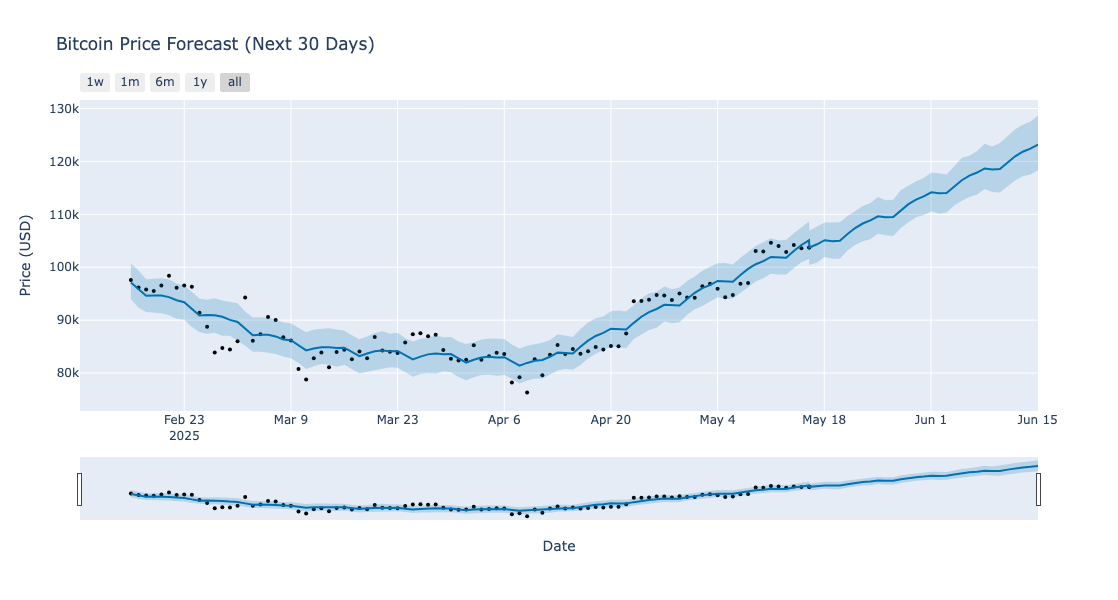

In [48]:
from prophet.plot import plot_plotly

fig = plot_plotly(model, forecast)
fig.update_layout(title="Bitcoin Price Forecast (Next 30 Days)", xaxis_title="Date", yaxis_title="Price (USD)")
fig.show()




In [23]:
!pip install jupyterlab_widgets



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [17]:
import ipywidgets as widgets
from IPython.display import display

# Create the slider widget
slider = widgets.IntSlider(value=30, min=7, max=90, step=7, description='Forecast Days:')
display(slider)

# Callback function to update forecast on slider change
def update_forecast(change):
    forecast_days = change.new
    future = model.make_future_dataframe(periods=forecast_days)
    new_forecast = model.predict(future)
    fig = plot_plotly(model, new_forecast)
    fig.update_layout(title=f"Bitcoin Forecast (Next {forecast_days} Days)", 
                      xaxis_title="Date", 
                      yaxis_title="Price (USD)")
    fig.show()

# Attach the callback to the slider
slider.observe(update_forecast, names='value')


IntSlider(value=30, description='Forecast Days:', max=90, min=7, step=7)

In [49]:
pip install --upgrade pip


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/baburaoramod/.local/lib/python3.12/site-packages/pip/__main__.py", line 8, in <module>
    if sys.path[0] in ("", os.getcwd()):
                           ^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory


python(89060) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Note: you may need to restart the kernel to use updated packages.
